# Prueba E - Awto traces RM

## Objetivo

Se construye una prueba end-to-end sobre trazas de Awto para mostrar el segundo modo de inferencia del módulo, basado en **`consecutive_clusters`**. El objetivo no es producir una gran segmentación temática, sino demostrar que una fuente de telemetría vehicular requiere una estrategia de inferencia distinta a la usada en Foursquare o telefonía.

Esta prueba busca mostrar que el módulo puede:

1. importar una fuente de puntos vehiculares,
2. validar su estructura mínima como trazas,
3. inferir viajes simples usando agrupación secuencial por clusters,
4. derivar flows persistibles y visualizables,
5. y comparar opcionalmente el baseline full-day con una punta AM.

En esta prueba el análisis es **no ponderado**. Por ello, los flows deben interpretarse como conteos observados derivados de trazas de telemetría, no como estimaciones expandidas a población.

## Contexto y preprocess integrado

En esta prueba el preprocess no queda asumido fuera del notebook. Se integra explícitamente una versión ordenada del trabajo ya realizado en `7_traces_awto.ipynb`.

La lógica general del preprocess es la siguiente:

- cargar una muestra TSV de Awto;
- expandir la columna JSON `data`;
- construir un dataframe plano con variables de telemetría;
- derivar `event_time_utc` desde `timestamp`;
- conservar un subconjunto resumido de columnas relevantes;
- filtrar espacialmente a una bbox de la RM;
- seleccionar una semana razonable;
- y dejar como resultado final el dataframe `df_week`, que será la entrada al bloque de trazas del módulo.

La fuente no se presenta aquí como viajes nativos. Lo que existe inicialmente es una secuencia de puntos vehiculares con tiempo, posición y algunos atributos operacionales de contexto.

In [3]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import display

REPO_ROOT = Path("../..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DATA_PATH = REPO_ROOT / "data" / "awto"
RAW_TSV_PATH = DATA_PATH / "awto_sample_1M.tsv"

ARTIFACTS_ROOT = REPO_ROOT / "data" / "flows" / "demo_7_awto_traces"
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 140)

from pylondrina.importing_traces import import_traces_from_dataframe, ImportTraceOptions
from pylondrina.validation_traces import validate_traces, TraceValidationOptions
from pylondrina.transforms.inference import infer_trips_from_traces, InferTripsOptions
from pylondrina.validation import validate_trips, ValidationOptions
from pylondrina.transforms.cleaning import clean_trips, CleanOptions
from pylondrina.transforms.filtering import filter_trips, FilterOptions
from pylondrina.transforms.flows import build_flows, FlowBuildOptions
from pylondrina.io.flows import write_flows, WriteFlowsOptions
from pylondrina.schema import TraceSchema, TripSchema, FieldSpec

## Carga y flatten del dataset crudo

Se parte de una muestra TSV donde gran parte de la información vehicular viene encapsulada en una columna JSON. El primer paso del preprocess consiste en expandir esa estructura y construir un dataframe plano.

In [4]:
import csv
import json

records = []

with open(RAW_TSV_PATH, "r", encoding="utf-8", errors="replace", newline="") as f:
    reader = csv.DictReader(f, delimiter="\t")

    for row in reader:
        payload_raw = row.get("data")

        try:
            payload = json.loads(payload_raw) if payload_raw else {}
        except Exception:
            payload = {}

        rec = {
            "device_id_outer": row.get("device_id"),
            "date_outer": row.get("date"),
            **payload,
        }
        records.append(rec)

df = pd.DataFrame(records)

display(df.head())
print("Shape raw flattened:", df.shape)

,device_id_outer,date_outer,Operator,battery_current,battery_voltage,channel_id,device_id,device_name,device_type_id,din,din_1,din_2,din_3,dout,dout_1,dout_2,dout_3,engine_ignition_status,event_enum,event_priority_enum,external_powersource_voltage,gnss_state_enum,gnss_status,gsm_mcc,gsm_mnc,gsm_network_type,gsm_operator_code,gsm_signal_level,ident,movement_status,overspeeding_speed,overspeeding_status,peer,position_altitude,position_direction,position_hdop,position_latitude,position_longitude,position_pdop,position_satellites,position_speed,position_valid,protocol_id,server_timestamp,sleep_mode_enum,timestamp,vehicle_mileage,gps_signal,last_date_ignition_on,vehicle_insecure,can_engine_rpm,can_engine_temperature,can_front_left_door_status,can_front_right_door_status,can_fuel_consumed,can_fuel_level,can_hood_status,can_module_id,can_program_id,can_rear_left_door_status,can_rear_right_door_status,can_throttle_pedal_level,can_trunk_status,can_vehicle_mileage,can_vehicle_speed,door_open_status,towing_alarm_status,custom_param_258,custom_param_259,custom_param_260,harsh_cornering_event,harsh_braking_event,average_x_acceleration,average_y_acceleration,average_z_acceleration,eco_driving_event_duration,max_x_acceleration,max_y_acceleration,max_z_acceleration,can_cng_status,can_engine_oil_level,can_fuel_volume,fuel_level_percentage,harsh_acceleration_event,can_engine_motorhours,can_tracker_counted_fuel_consumed,can_tracker_counted_mileage,can_trip_engine_motorhours,idle_status,crash_event,crash_event_enum,crash_events_number,absolute_acceleration,gsm_jamming_alarm_status,dout_4,external_powersource_status,gnss_antenna_status
0,2081353,2023-02-05 16:11:21.000,Movistar,0,4.042,52965,2081353,RGDK86,505,3.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,255.0,0,13.735,1.0,1.0,730.0,2.0,3G,73002,80.0,866381051416557,1.0,85.0,0.0,2.140.214.138:20683,284,308,0.6,-33.24118,-71.452742,1.3,17,85,1.0,14,1675613488,0.0,1675613481,43135.878,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2378141,2023-02-14 02:44:12.000,NaN,0,3.954,52965,2378141,KBKP63,505,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0,13.334,1.0,1.0,0.0,0.0,NaN,00000,0.0,866381054676157,0.0,NaN,NaN,81.47.30.120:56437,83,172,0.6,-41.272322,-72.9926,0.9,19,0,1.0,14,1697576956,0.0,1676342652,26883.874,1.0,null,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2407421,2023-02-05 20:49:58.000,Movistar,0,4.014,52965,2407421,RJHR53,505,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,0,13.449,1.0,1.0,730.0,2.0,3G,73002,80.0,866381054631244,1.0,NaN,NaN,176.83.209.27:15235,682,191,0.7,-33.413485,-70.558658,1,14,0,1.0,14,1675630204,0.0,1675630198,34750.575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2082085,2022-12-02 19:11:24.000,NaN,0,3.971,52965,2082085,RZDD85,505,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,0,13.811,1.0,1.0,730.0,2.0,NaN,73002,80.0,866381051416482,1.0,NaN,NaN,95.126.114.151:56854,853,245,0.5,-33.404045,-70.516687,0.9,21,12,1.0,14,1670008287,NaN,1670008284,6987.453,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2936629,2022-12-07 18:02:38.000,NaN,0,4.014,52965,2936629,LSDL60,505,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,0,13.481,1.0,1.0,730.0,2.0,NaN,73002,100.0,864606045262952,1.0,NaN,NaN,95.126.120.78:15013,495,344,0.5,-33.353162,-70.677928,1.2,19,10,1.0,14,1670436160,NaN,1670436158,2199.417,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N

Shape raw flattened: (999999, 97)


## Construcción del dataframe resumido de telemetría

Se deriva `event_time_utc` desde `timestamp` y se conserva un subconjunto de columnas suficiente para esta prueba. El objetivo no es agotar toda la semántica vehicular, sino dejar una tabla de puntos temporales y espaciales consistente con el flujo posterior del módulo.

In [5]:
if "timestamp" in df.columns:
    df["event_time_utc"] = pd.to_datetime(df["timestamp"], unit="s", errors="coerce")

cols_resumen = [
    c for c in [
        "device_id_outer",
        "event_time_utc",
        "position_latitude",
        "position_longitude",
        "position_speed",
        "movement_status",
        "engine_ignition_status",
        "vehicle_mileage",
        "battery_current",
        "battery_voltage",
    ]
    if c in df.columns
]

df_resume = df[cols_resumen].copy()

display(df_resume.head())
print("Shape resumen:", df_resume.shape)

,device_id_outer,event_time_utc,position_latitude,position_longitude,position_speed,movement_status,engine_ignition_status,vehicle_mileage,battery_current,battery_voltage
0,2081353,2023-02-05 16:11:21,-33.24118,-71.452742,85,1.0,1.0,43135.878,0,4.042
1,2378141,2023-02-14 02:44:12,-41.272322,-72.9926,0,0.0,0.0,26883.874,0,3.954
2,2407421,2023-02-05 20:49:58,-33.413485,-70.558658,0,1.0,1.0,34750.575,0,4.014
3,2082085,2022-12-02 19:11:24,-33.404045,-70.516687,12,1.0,1.0,6987.453,0,3.971
4,2936629,2022-12-07 18:02:38,-33.353162,-70.677928,10,1.0,1.0,2199.417,0,4.014


Shape resumen: (999999, 10)


## Delimitación espacial de la RM

Se usa una lista de comunas metropolitanas para construir un bounding box de referencia y conservar solo los puntos que caen dentro de esa extensión espacial.

In [6]:
import geopandas as gpd
import osmnx as ox
from typing import Iterable

municipalities = """
Cerrillos
La Reina
Pudahuel
Cerro Navia
Las Condes
Quilicura
Conchalí
Lo Barnechea
Quinta Normal
El Bosque
Lo Espejo
Recoleta
Estación Central
Lo Prado
Renca
Huechuraba
Macul
San Miguel (Chile)
Independencia (Chile)
Maipú
San Joaquín (Chile)
La Cisterna
Ñuñoa
San Ramón (Chile)
La Florida
Pedro Aguirre Cerda
Santiago, Provincia de Santiago, Región Metropolitana de Santiago, Chile
La Pintana
Peñalolén
Vitacura
La Granja (Chile)
Providencia, Provincia de Santiago, Región Metropolitana de Santiago, Chile
Peñaflor (Chile)
San Bernardo (Chile)
Padre Hurtado
Puente Alto
""".strip().split("\n")


def get_municipalities_gdf(municipalities: Iterable[str]) -> gpd.GeoDataFrame:
    amb = ox.geocoder.geocode_to_gdf(list(municipalities))
    return amb.to_crs("EPSG:4326")


municipalities_gdf = get_municipalities_gdf(municipalities)
minx, miny, maxx, maxy = municipalities_gdf.total_bounds

print("BBox RM objetivo:")
print((minx, miny, maxx, maxy))

BBox RM objetivo:
(np.float64(-70.9678545), np.float64(-33.7540753), np.float64(-70.1758683), np.float64(-33.0969351))


In [7]:
df_resume["position_longitude"] = pd.to_numeric(df_resume["position_longitude"], errors="coerce")
df_resume["position_latitude"] = pd.to_numeric(df_resume["position_latitude"], errors="coerce")
df_resume["position_speed"] = pd.to_numeric(df_resume.get("position_speed"), errors="coerce")
df_resume["vehicle_mileage"] = pd.to_numeric(df_resume.get("vehicle_mileage"), errors="coerce")
df_resume["battery_current"] = pd.to_numeric(df_resume.get("battery_current"), errors="coerce")
df_resume["battery_voltage"] = pd.to_numeric(df_resume.get("battery_voltage"), errors="coerce")

df_points_bbox = df_resume[
    df_resume["position_longitude"].between(minx, maxx) &
    df_resume["position_latitude"].between(miny, maxy)
].copy()

display(df_points_bbox.head())
print("Shape puntos RM:", df_points_bbox.shape)

,device_id_outer,event_time_utc,position_latitude,position_longitude,position_speed,movement_status,engine_ignition_status,vehicle_mileage,battery_current,battery_voltage
2,2407421,2023-02-05 20:49:58,-33.413485,-70.558658,0,1.0,1.0,34750.575,0.0,4.014
3,2082085,2022-12-02 19:11:24,-33.404045,-70.516687,12,1.0,1.0,6987.453,0.0,3.971
4,2936629,2022-12-07 18:02:38,-33.353162,-70.677928,10,1.0,1.0,2199.417,0.0,4.014
6,3189641,2022-12-08 14:00:59,-33.449512,-70.610580,0,1.0,1.0,607.949,0.0,4.091
8,2313909,2023-02-03 07:06:31,-33.329013,-70.503523,0,0.0,0.0,20663.172,0.0,4.043


Shape puntos RM: (708729, 10)


## Selección de la semana base

A partir del subconjunto espacial metropolitano, se selecciona una semana razonable para mantener el volumen operable. Esta semana será el universo base de toda la prueba.

In [8]:
week_start = pd.Timestamp("2022-12-12 00:00:00")
week_end = week_start + pd.Timedelta(days=7)

df_week = df_points_bbox[
    (df_points_bbox["event_time_utc"] >= week_start) &
    (df_points_bbox["event_time_utc"] < week_end)
].copy()

df_week = df_week.drop_duplicates(
    subset=[
        "device_id_outer",
        "event_time_utc",
        "position_latitude",
        "position_longitude",
    ],
    keep="first",
).reset_index(drop=True)

df_week["point_id_src"] = [f"awto_p{i}" for i in range(len(df_week))]

display(df_week.head())
print("Shape semana RM:", df_week.shape)

,device_id_outer,event_time_utc,position_latitude,position_longitude,position_speed,movement_status,engine_ignition_status,vehicle_mileage,battery_current,battery_voltage,point_id_src
0,4656616,2022-12-18 16:38:25,-33.442575,-70.543595,0,0.0,0.0,6065.590,0.0,4.037,awto_p0
1,2121401,2022-12-12 10:10:22,-33.405940,-70.521437,0,0.0,0.0,31629.241,0.0,3.929,awto_p1
2,4669190,2022-12-16 16:37:42,-33.416143,-70.606748,11,1.0,1.0,3532.711,0.0,4.005,awto_p2
3,2439753,2022-12-12 23:32:59,-33.431198,-70.587790,19,1.0,1.0,27950.107,0.0,4.005,awto_p3
4,2905381,2022-12-13 01:23:59,-33.592780,-70.676872,0,0.0,0.0,16480.976,0.0,3.952,awto_p4


Shape semana RM: (64647, 11)


## Exploración mínima del input final

Antes de entrar al módulo, conviene dejar visible la cobertura temporal del subconjunto y algunos conteos simples sobre variables vehiculares que pueden servir luego para contextualizar la fuente.

In [10]:
raw_time_range = pd.Series(
    {
        "min_event_time_utc_raw": pd.to_datetime(df_resume["event_time_utc"], utc=True, errors="coerce").min(),
        "max_event_time_utc_raw": pd.to_datetime(df_resume["event_time_utc"], utc=True, errors="coerce").max(),
        "min_event_time_utc_week": pd.to_datetime(df_week["event_time_utc"], utc=True, errors="coerce").min(),
        "max_event_time_utc_week": pd.to_datetime(df_week["event_time_utc"], utc=True, errors="coerce").max(),
        "n_rows_week": len(df_week),
        "n_devices_week": df_week["device_id_outer"].nunique(dropna=True),
    },
    name="value",
)

display(raw_time_range.to_frame())

speed_non_null = pd.to_numeric(df_week["position_speed"], errors="coerce").notna().sum()
speed_gt_0 = (pd.to_numeric(df_week["position_speed"], errors="coerce") > 0).sum()

battery_non_null = pd.to_numeric(df_week["battery_current"], errors="coerce").notna().sum()
battery_gt_0 = (pd.to_numeric(df_week["battery_current"], errors="coerce") > 0).sum()

display(
    pd.DataFrame(
        [
            {"metric": "position_speed_not_null", "value": int(speed_non_null)},
            {"metric": "position_speed_gt_0", "value": int(speed_gt_0)},
            {"metric": "battery_current_not_null", "value": int(battery_non_null)},
            {"metric": "battery_current_gt_0", "value": int(battery_gt_0)},
        ]
    )
)

,value
min_event_time_utc_raw,2022-12-01 00:00:18+00:00
max_event_time_utc_raw,2023-02-27 20:19:56+00:00
min_event_time_utc_week,2022-12-12 00:00:01+00:00
max_event_time_utc_week,2022-12-18 23:59:54+00:00
n_rows_week,64647
n_devices_week,736


,metric,value
0,position_speed_not_null,64647
1,position_speed_gt_0,44235
2,battery_current_not_null,64642
3,battery_current_gt_0,109


Se obtiene así el dataframe `df_week`, que actúa como fuente final de entrada para la prueba E. A partir de este punto, el notebook entra al bloque de trazas del módulo: importación, validación, inferencia cluster-based y derivación de flows.

In [11]:
def _issues_to_frame(report):
    issues = getattr(report, "issues", None) or []
    if not issues:
        return pd.DataFrame(columns=["level", "code", "field", "row_count", "message"])
    rows = []
    for issue in issues:
        rows.append(
            {
                "level": getattr(issue, "level", None),
                "code": getattr(issue, "code", None),
                "field": getattr(issue, "field", None),
                "row_count": getattr(issue, "row_count", None),
                "message": getattr(issue, "message", None),
            }
        )
    return pd.DataFrame(rows)


def show_report_digest(report, title: str, top_n_issues: int = 10):
    print(f"\n===== {title} =====")
    print("ok:", getattr(report, "ok", None))
    summary = getattr(report, "summary", None)
    if summary is not None:
        print("summary:")
        display(pd.DataFrame([summary]))
    parameters = getattr(report, "parameters", None)
    if parameters is not None:
        print("parameters:")
        display(pd.DataFrame([parameters]))
    issues_df = _issues_to_frame(report)
    print("n_issues:", len(issues_df))
    if not issues_df.empty:
        print("issue_counts_by_level:")
        display(
            issues_df["level"]
            .astype(str)
            .value_counts(dropna=False)
            .rename_axis("level")
            .reset_index(name="count")
        )
        print("top_issues:")
        display(issues_df.head(top_n_issues))


def compute_flow_validation_bundle(flow_dataset, *, top_k: int = 20, coverage_top_n: int = 100):
    flows_df = flow_dataset.flows.copy()

    if len(flows_df) == 0:
        summary = pd.DataFrame(
            [{"flow_rows": 0, "total_flow_value": 0.0, f"top_{coverage_top_n}_coverage_ratio": 0.0, "intrazona_ratio": 0.0}]
        )
        empty = pd.DataFrame()
        return summary, empty, empty, empty

    flows_df["flow_value"] = pd.to_numeric(flows_df["flow_value"], errors="coerce").fillna(0.0)
    flows_df["flow_count"] = pd.to_numeric(flows_df["flow_count"], errors="coerce").fillna(0)

    total_mass = float(flows_df["flow_value"].sum())
    n_flows = int(len(flows_df))
    n_top = min(coverage_top_n, n_flows)

    flows_sorted = flows_df.sort_values("flow_value", ascending=False).copy()
    top_flows = flows_sorted.head(top_k).copy()

    top_mass = float(flows_sorted.head(n_top)["flow_value"].sum())
    coverage_ratio = (top_mass / total_mass) if total_mass > 0 else 0.0

    top_origins = (
        flows_df.groupby("origin_h3_index", dropna=False)["flow_value"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index(name="flow_value")
    )

    top_destinations = (
        flows_df.groupby("destination_h3_index", dropna=False)["flow_value"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index(name="flow_value")
    )

    intrazona_mass = float(
        flows_df.loc[
            flows_df["origin_h3_index"] == flows_df["destination_h3_index"], "flow_value"
        ].sum()
    )
    intrazona_ratio = (intrazona_mass / total_mass) if total_mass > 0 else 0.0

    summary = pd.DataFrame(
        [
            {
                "flow_rows": n_flows,
                "total_flow_value": total_mass,
                f"top_{n_top}_coverage_ratio": coverage_ratio,
                "intrazona_ratio": intrazona_ratio,
            }
        ]
    )

    cols_top = [c for c in ["flow_id", "origin_h3_index", "destination_h3_index", "flow_count", "flow_value"] if c in top_flows.columns]
    top_flows = top_flows[cols_top].reset_index(drop=True)

    return summary, top_flows, top_origins, top_destinations

## Preparación del import de trazas

Se define un esquema mínimo de trazas. Las variables vehiculares extra se conservan, pero el núcleo contractual del import sigue siendo: identificador de punto, usuario, tiempo y coordenadas.

In [13]:
AWTO_TRACE_SCHEMA = TraceSchema(
    version="awto-traces-e1",
    fields={
        "point_id": FieldSpec(
            "point_id",
            "string",
            required=True,
            constraints={
                "nullable": False,
                "unique": True,
                "length": {"min": 1, "max": 120},
            },
        ),
        "user_id": FieldSpec(
            "user_id",
            "string",
            required=True,
            constraints={
                "nullable": False,
                "length": {"min": 1, "max": 120},
            },
        ),
        "time_utc": FieldSpec(
            "time_utc",
            "datetime",
            required=True,
            constraints={
                "nullable": False,
                "datetime": {"allow_naive": False},
            },
        ),
        "latitude": FieldSpec(
            "latitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -90.0, "max": 90.0},
            },
        ),
        "longitude": FieldSpec(
            "longitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -180.0, "max": 180.0},
            },
        ),
    },
    required=["point_id", "user_id", "time_utc", "latitude", "longitude"],
    timezone="UTC",
)

AWTO_TRACE_FIELD_CORR = {
    "user_id": "device_id_outer",
    "time_utc": "event_time_utc",
    "latitude": "position_latitude",
    "longitude": "position_longitude",
}

AWTO_TRACE_OPTIONS = ImportTraceOptions(
    keep_extra_fields=True,
    selected_fields=None,
    strict=False,
    source_timezone="UTC",
)

AWTO_TRACE_PROVENANCE = {
    "source": {
        "name": "Awto",
        "entity": "traces",
        "version": "rm_week_sample_1m",
    },
    "notes": [
        "telemetría vehicular",
        "análisis no ponderado",
        "puntos filtrados espacialmente a RM",
    ],
}

display(
    pd.DataFrame(
        {
            "field": list(AWTO_TRACE_FIELD_CORR.keys()),
            "source_field": list(AWTO_TRACE_FIELD_CORR.values()),
        }
    )
)

,field,source_field
0,user_id,device_id_outer
1,time_utc,event_time_utc
2,latitude,position_latitude
3,longitude,position_longitude


## Importación del dataset de trazas

Se importa el dataframe final del preprocess hacia un `TraceDataset`. En esta etapa todavía no existen viajes; la fuente sigue expresada como una tabla de puntos vehiculares.

In [14]:
awto_traces, awto_import_report = import_traces_from_dataframe(
    df_week,
    schema=AWTO_TRACE_SCHEMA,
    source_name="Awto",
    options=AWTO_TRACE_OPTIONS,
    field_correspondence=AWTO_TRACE_FIELD_CORR,
    provenance=AWTO_TRACE_PROVENANCE,
)

show_report_digest(awto_import_report, "Reporte de importación de trazas")

print("\nTraceDataset importado")
print("shape:", awto_traces.data.shape)
print("metadata['is_validated']:", awto_traces.metadata.get("is_validated"))
print("metadata keys:", sorted(awto_traces.metadata.keys()))

display(awto_traces.data.head())


===== Reporte de importación de trazas =====
ok: True
summary:


,rows_in,rows_out,n_fields_mapped,point_id_generated
0,64647,64647,4,True


parameters:


,source_name,strict,keep_extra_fields,selected_fields,source_timezone,schema_version,crs,timezone,has_field_correspondence
0,Awto,False,True,None,UTC,awto-traces-e1,EPSG:4326,UTC,True


n_issues: 1
issue_counts_by_level:


,level,count
0,info,1


top_issues:


,level,code,field,row_count,message
0,info,IMP.CORE.POINT_ID_GENERATED,point_id,None,No se encontró point_id alcanzable; se generó automáticamente una columna técnica secuencial.



TraceDataset importado
shape: (64647, 12)
metadata['is_validated']: False
metadata keys: ['dataset_id', 'events', 'field_correspondence_applied', 'is_validated', 'point_id_generated', 'schema_version', 'source', 'temporal']


,point_id,user_id,time_utc,latitude,longitude,position_speed,movement_status,engine_ignition_status,vehicle_mileage,battery_current,battery_voltage,point_id_src
0,p0,4656616,2022-12-18 16:38:25+00:00,-33.442575,-70.543595,0,0.0,0.0,6065.590,0.0,4.037,awto_p0
1,p1,2121401,2022-12-12 10:10:22+00:00,-33.405940,-70.521437,0,0.0,0.0,31629.241,0.0,3.929,awto_p1
2,p2,4669190,2022-12-16 16:37:42+00:00,-33.416143,-70.606748,11,1.0,1.0,3532.711,0.0,4.005,awto_p2
3,p3,2439753,2022-12-12 23:32:59+00:00,-33.431198,-70.587790,19,1.0,1.0,27950.107,0.0,4.005,awto_p3
4,p4,2905381,2022-12-13 01:23:59+00:00,-33.592780,-70.676872,0,0.0,0.0,16480.976,0.0,3.952,awto_p4


## Validación de trazas

Se valida el `TraceDataset` para revisar required, tipos y monotonicidad temporal por usuario. En una fuente de telemetría vehicular, esta etapa es especialmente importante porque la inferencia posterior depende de secuencias ordenadas y razonables.

In [15]:
awto_trace_validate_options = TraceValidationOptions(
    strict=False,
    sample_rows_per_issue=5,
    validate_required_fields=True,
    validate_types_and_formats=True,
    validate_constraints=True,
    validate_monotonic_time_per_user=True,
)

awto_validate_traces_report = validate_traces(
    awto_traces,
    options=awto_trace_validate_options,
)

show_report_digest(awto_validate_traces_report, "Validación de trazas")

print("\nEstado validado después de validate_traces:")
print("metadata['is_validated']:", awto_traces.metadata.get("is_validated"))


===== Validación de trazas =====
ok: None
summary:


,ok,n_rows,n_issues,n_errors,n_warnings,n_info,counts_by_level,counts_by_code,checked_fields,checks_executed,schema_version
0,True,64647,1,0,1,0,"{'error': 0, 'warning': 1, 'info': 0}",{'VAL.TEMPORAL.NON_MONOTONIC_TIME': 1},"[point_id, user_id, time_utc, latitude, longitude]","{'required_fields': True, 'types_and_formats': True, 'constraints': True, 'monotonic_time_per_user': True}",awto-traces-e1


parameters:


""
0


n_issues: 1
issue_counts_by_level:


,level,count
0,warning,1


top_issues:


,level,code,field,row_count,message
0,warning,VAL.TEMPORAL.NON_MONOTONIC_TIME,time_utc,31540,Se detectaron secuencias temporales no monotónicas por usuario en 'time_utc'.



Estado validado después de validate_traces:
metadata['is_validated']: True


## Inferencia de viajes con `consecutive_clusters`

A diferencia de Foursquare y telefonía, aquí la inferencia se apoya en clusters consecutivos. La idea es absorber puntos cercanos en espacio y tiempo dentro de estados locales más estables, y luego construir viajes entre esos estados.

In [16]:
AWTO_TRIPS_SCHEMA = TripSchema(
    version="awto-inferred-trips-e1",
    fields={
        "movement_id": FieldSpec(
            "movement_id",
            "string",
            required=True,
            constraints={
                "nullable": False,
                "unique": True,
                "length": {"min": 1, "max": 120},
            },
        ),
        "trip_id": FieldSpec(
            "trip_id",
            "string",
            required=True,
            constraints={
                "nullable": False,
                "length": {"min": 1, "max": 120},
            },
        ),
        "movement_seq": FieldSpec(
            "movement_seq",
            "int",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": 0},
            },
        ),
        "user_id": FieldSpec(
            "user_id",
            "string",
            required=True,
            constraints={
                "nullable": False,
                "length": {"min": 1, "max": 120},
            },
        ),
        "origin_longitude": FieldSpec(
            "origin_longitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -180.0, "max": 180.0},
            },
        ),
        "origin_latitude": FieldSpec(
            "origin_latitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -90.0, "max": 90.0},
            },
        ),
        "destination_longitude": FieldSpec(
            "destination_longitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -180.0, "max": 180.0},
            },
        ),
        "destination_latitude": FieldSpec(
            "destination_latitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -90.0, "max": 90.0},
            },
        ),
        "origin_time_utc": FieldSpec(
            "origin_time_utc",
            "datetime",
            required=False,
            constraints={
                "nullable": True,
                "datetime": {"allow_naive": False},
            },
        ),
        "destination_time_utc": FieldSpec(
            "destination_time_utc",
            "datetime",
            required=False,
            constraints={
                "nullable": True,
                "datetime": {"allow_naive": False},
            },
        ),
        "origin_h3_index": FieldSpec(
            "origin_h3_index",
            "string",
            required=False,
            constraints={
                "nullable": True,
                "h3": {"require_valid": True, "resolution": 10},
            },
        ),
        "destination_h3_index": FieldSpec(
            "destination_h3_index",
            "string",
            required=False,
            constraints={
                "nullable": True,
                "h3": {"require_valid": True, "resolution": 10},
            },
        ),
    },
    required=[
        "movement_id",
        "trip_id",
        "movement_seq",
        "user_id",
        "origin_longitude",
        "origin_latitude",
        "destination_longitude",
        "destination_latitude",
    ],
)

AWTO_INFER_OPTIONS = InferTripsOptions(
    infer_mode="consecutive_clusters",
    strict=False,
    strict_domains=False,
    require_validated_traces=True,
    drop_invalid=True,
    h3_resolution=10,
    min_time_delta_s=300.0,
    max_time_delta_s=60.0 * 60.0 * 12.0 ,
    min_distance_m=300.0,
    cluster_radius_m=150.0,
    cluster_max_time_gap_s=1800.0,
    propagate_trace_fields={"position_speed" : "both"},
)

AWTO_INFER_PROVENANCE = {
    "source": {
        "name": "Awto",
        "entity": "inferred_trips",
        "version": "rm_week_consecutive_clusters",
    },
    "notes": [
        "inferencia cluster-based",
        "telemetría vehicular",
        "análisis no ponderado",
    ],
}

In [17]:
awto_trips_inferred, awto_infer_report = infer_trips_from_traces(
    awto_traces,
    AWTO_TRIPS_SCHEMA,
    options=AWTO_INFER_OPTIONS,
    value_correspondence=None,
    provenance=AWTO_INFER_PROVENANCE,
)

show_report_digest(awto_infer_report, "Inferencia de viajes desde trazas - consecutive_clusters")

print("\nTripDataset inferido")
print("shape:", awto_trips_inferred.data.shape)
print("is_validated:", awto_trips_inferred.metadata.get("is_validated"))
print("metadata keys:", sorted(awto_trips_inferred.metadata.keys()))

display(awto_trips_inferred.data.head())


===== Inferencia de viajes desde trazas - consecutive_clusters =====
ok: True
summary:


,infer_mode,n_points_in,n_candidates_in,n_candidates_dropped,n_trips_out,dropped_by_reason,n_clusters_out
0,consecutive_clusters,64647,57955,18864,39091,"{'max_time_delta_s': 1441, 'min_time_delta_s': 17340, 'min_distance_m': 129}",58691


parameters:


,infer_mode,strict,strict_domains,require_validated_traces,drop_invalid,h3_resolution,max_time_delta_s,min_time_delta_s,min_distance_m,cluster_radius_m,cluster_max_time_gap_s,propagate_trace_fields,value_correspondence_used,validation_bypass_used
0,consecutive_clusters,False,False,True,True,10,43200.0,300.0,300.0,150.0,1800.0,{'position_speed': 'both'},False,False


n_issues: 7
issue_counts_by_level:


,level,count
0,info,7


top_issues:


,level,code,field,row_count,message
0,info,INF.CLUSTERS.MODE_APPLIED,None,None,Se construyeron 58691 clusters secuenciales y 57955 candidatos OD entre clusters consecutivos.
1,info,INF.CANDIDATES.DROPPED_MAX_TIME_DELTA,None,None,Se descartaron 1441 candidatos por exceder max_time_delta_s=43200.0.
2,info,INF.CANDIDATES.DROPPED_MIN_TIME_DELTA,None,None,Se descartaron 17340 candidatos por quedar bajo min_time_delta_s=300.0.
3,info,INF.CANDIDATES.DROPPED_MIN_DISTANCE,None,None,Se descartaron 129 candidatos por quedar bajo min_distance_m=300.0.
4,info,INF.PROPAGATION.APPLIED,None,None,Se propagaron campos extra desde traces hacia el output de trips (nuevas columnas=2).
5,info,INF.H3.DERIVED,None,None,Se derivaron origin_h3_index y destination_h3_index con h3_resolution=10.
6,info,INF.OK.SUMMARY,None,None,Se infirieron 39091 viajes a partir de 64647 puntos usando infer_mode='consecutive_clusters'.



TripDataset inferido
shape: (39091, 14)
is_validated: False
metadata keys: ['dataset_id', 'events', 'h3', 'is_validated', 'mappings', 'temporal']


,movement_id,user_id,origin_longitude,origin_latitude,destination_longitude,destination_latitude,origin_time_utc,destination_time_utc,trip_id,movement_seq,origin_position_speed,destination_position_speed,origin_h3_index,destination_h3_index
0,m0,1769093,-70.721190,-33.467117,-70.545475,-33.367218,2022-12-12 02:17:57+00:00,2022-12-12 05:14:15+00:00,m0,0,8,42,8ab2c555e177fff,8ab2c518256ffff
1,m1,1769093,-70.545475,-33.367218,-70.581340,-33.426160,2022-12-12 05:14:15+00:00,2022-12-12 10:30:20+00:00,m1,0,42,0,8ab2c518256ffff,8ab2c5569a17fff
2,m2,1769093,-70.581340,-33.426160,-70.560653,-33.406572,2022-12-12 10:30:20+00:00,2022-12-12 10:42:09+00:00,m2,0,0,12,8ab2c5569a17fff,8ab2c519e2d7fff
3,m3,1769093,-70.622673,-33.428895,-70.526918,-33.376817,2022-12-12 10:47:55+00:00,2022-12-12 10:54:35+00:00,m3,0,0,62,8ab2c556aae7fff,8ab2c5183557fff
4,m4,1769093,-70.526918,-33.376817,-70.638803,-33.436908,2022-12-12 10:54:35+00:00,2022-12-12 11:03:28+00:00,m4,0,62,31,8ab2c5183557fff,8ab2c556a6affff


Se observa así el núcleo conceptual de esta prueba: la misma librería puede absorber una fuente de telemetría vehicular, pero usando un modo de inferencia distinto al de otras trazas discretas. Esa diferencia metodológica es justamente el aporte principal del notebook E.

## Validación inicial de trips inferidos

Antes de derivar flows, se valida el dataset inferido para revisar estructura mínima, coherencia temporal y constraints relevantes del contrato de salida.

In [18]:
awto_validate_trips_options = ValidationOptions(
    strict=False,
    max_issues=300,
    sample_rows_per_issue=5,
    validate_required_fields=True,
    validate_types_and_formats=True,
    validate_constraints=True,
    validate_domains="sample",
    domains_sample_frac=0.02,
    domains_min_in_domain_ratio=0.95,
    validate_temporal_consistency=True,
    validate_duplicates=True,
    duplicates_subset=("movement_id",),
)

awto_validation_report_initial = validate_trips(
    awto_trips_inferred,
    options=awto_validate_trips_options,
)

show_report_digest(awto_validation_report_initial, "Validación inicial de trips inferidos")

print("\nEstado validado después de validate_trips:")
print("is_validated:", awto_trips_inferred.is_validated)
print("metadata['is_validated']:", awto_trips_inferred.metadata.get("is_validated"))


===== Validación inicial de trips inferidos =====
ok: True
summary:


,ok,n_rows,n_issues,n_errors,n_warnings,n_info,counts_by_level,counts_by_code,checked_fields,checks_executed,schema_version,domains,duplicates,temporal,limits
0,True,39091,0,0,0,0,"{'error': 0, 'warning': 0, 'info': 0}",{},"[destination_h3_index, destination_latitude, destination_longitude, destination_time_utc, movement_id, movement_seq, origin_h3_index, or...","{'required_fields': True, 'types_and_formats': True, 'constraints': True, 'domains': True, 'temporal_consistency': True, 'duplicates': T...",awto-inferred-trips-e1,"{'mode': 'sample', 'min_required_ratio': 0.95, 'fields': {}}","{'evaluated': True, 'duplicates_subset': ['movement_id'], 'n_duplicate_rows': 0}","{'evaluated': True, 'tier': 'tier_1', 'n_checked': 39091, 'n_violations': 0, 'origin_field': 'origin_time_utc', 'destination_field': 'de...","{'max_issues': 300, 'issues_truncated': False, 'n_issues_emitted': 0, 'n_issues_detected_total': 0}"


n_issues: 0

Estado validado después de validate_trips:
is_validated: True
metadata['is_validated']: True


## Baseline y contraste temporal opcional

El baseline de esta prueba corresponde a todos los trips inferidos de la semana base. Como contraste temporal opcional, se deriva una punta PM (Entre 12 y 16 hrs) usando la hora local de inicio del viaje.

In [19]:
awto_baseline_trips = awto_trips_inferred

awto_baseline_trips.data["origin_time_local"] = (
    awto_baseline_trips.data["origin_time_utc"]
    .dt.tz_convert("America/Santiago")
)

awto_baseline_trips.data["local_hour"] = (
    awto_baseline_trips.data["origin_time_local"].dt.hour.astype("Int64")
)

display(
    awto_baseline_trips.data["local_hour"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("local_hour")
    .reset_index(name="count")
)

,local_hour,count
0,0,1057
1,1,819
2,2,655
3,3,614
4,4,620
5,5,529
6,6,693
7,7,1220
8,8,1722
9,9,1889


In [20]:
awto_peak_filter_options = FilterOptions(
    where={"local_hour": {"gte": 12, "lte": 16}},
    keep_metadata=True,
    strict=False,
)

awto_trips_peak, awto_filter_report_peak = filter_trips(
    awto_baseline_trips,
    options=awto_peak_filter_options,
)

show_report_digest(awto_filter_report_peak, "Filtro contraste - punta AM")

display(
    pd.DataFrame(
        [
            {
                "subset": "awto_peak_am",
                "rows": len(awto_trips_peak.data),
                "is_validated": awto_trips_peak.is_validated,
            }
        ]
    )
)


===== Filtro contraste - punta AM =====
ok: True
summary:


,rows_in,rows_out,dropped_total,dropped_by_filter,filters_requested,filters_applied,filters_omitted
0,39091,11422,27669,"{'where': 27669, 'time': 0, 'bbox': 0, 'polygon': 0, 'h3_cells': 0}",[where],[where],[]


parameters:


,where,time,bbox,polygon,h3_cells,spatial_predicate,origin_h3_field,destination_h3_field,keep_metadata,strict,max_issues,sample_rows_per_issue
0,"{'local_hour': {'gte': 12, 'lte': 16}}",None,None,None,None,origin,origin_h3_index,destination_h3_index,True,False,1000,20


n_issues: 1
issue_counts_by_level:


,level,count
0,info,1


top_issues:


,level,code,field,row_count,message
0,info,FLT.INFO.WHERE_APPLIED,None,None,Se aplicó la cláusula where y el subconjunto pasó de 39091 a 11422 filas en este eje.


,subset,rows,is_validated
0,awto_peak_am,11422,True


Se dejan así definidos dos artefactos analíticos:

- un baseline full-day de la semana base,
- y un contraste opcional entre 12 y 16 hrs.

El valor central del notebook sigue estando en el modo de inferencia, no en la segmentación.

## Construcción de flows

Se construyen flows no ponderados sobre el baseline y sobre la punta AM. En esta prueba, `flow_value` debe interpretarse como conteo observado agregado.

In [28]:
if not awto_baseline_trips.is_validated:
    raise RuntimeError("El baseline no quedó validado; no conviene construir flows con require_validated=True.")

if not awto_trips_peak.is_validated:
    raise RuntimeError("El contraste punta AM no quedó validado; no conviene construir flows con require_validated=True.")

awto_build_flow_options = FlowBuildOptions(
    h3_resolution=7,
    group_by=None,
    time_aggregation="none",
    keep_flow_to_trips=False,
    require_validated=True,
    min_trips_per_flow=3
)

awto_flows_baseline, awto_build_report_baseline = build_flows(
    awto_baseline_trips,
    options=awto_build_flow_options,
)

awto_flows_peak, awto_build_report_peak = build_flows(
    awto_trips_peak,
    options=awto_build_flow_options,
)

show_report_digest(awto_build_report_baseline, "Build flows - baseline")
show_report_digest(awto_build_report_peak, "Build flows - Entre 12 y 16 hrs")

print("\nColumnas FlowDataset baseline:")
print(awto_flows_baseline.flows.columns.tolist())

display(awto_flows_baseline.flows.head())


===== Build flows - baseline =====
ok: True
summary:


,n_trips_in,n_trips_eligible,n_trips_dropped,n_flows_out,n_flow_to_trips_rows
0,39091,39091,0,3413,None


parameters:


,h3_resolution,group_by,time_aggregation,time_basis,min_trips_per_flow,keep_flow_to_trips,require_validated,strict,max_issues
0,7,None,none,origin,3,False,True,False,1000


n_issues: 0

===== Build flows - Entre 12 y 16 hrs =====
ok: True
summary:


,n_trips_in,n_trips_eligible,n_trips_dropped,n_flows_out,n_flow_to_trips_rows
0,11422,11422,0,971,None


parameters:


,h3_resolution,group_by,time_aggregation,time_basis,min_trips_per_flow,keep_flow_to_trips,require_validated,strict,max_issues
0,7,None,none,origin,3,False,True,False,1000


n_issues: 0

Columnas FlowDataset baseline:
['flow_id', 'origin_h3_index', 'destination_h3_index', 'flow_count', 'flow_value']


,flow_id,origin_h3_index,destination_h3_index,flow_count,flow_value
0,flow_0000000,87b2c0b2effffff,87b2c5568ffffff,4,4.0
1,flow_0000001,87b2c5080ffffff,87b2c50b5ffffff,4,4.0
2,flow_0000002,87b2c5080ffffff,87b2c5181ffffff,3,3.0
3,flow_0000003,87b2c5080ffffff,87b2c519bffffff,4,4.0
4,flow_0000004,87b2c5080ffffff,87b2c519cffffff,3,3.0


## Persistencia formal de flows

Se persisten ambos flows con `write_flows`, que en estas pruebas actúa como mecanismo principal de persistencia formal.

In [29]:
E_BASELINE_FLOWS_PATH = ARTIFACTS_ROOT / "e_awto_baseline"
E_PEAK_FLOWS_PATH = ARTIFACTS_ROOT / "e_awto_12_16"

awto_write_flows_report_baseline = write_flows(
    awto_flows_baseline,
    E_BASELINE_FLOWS_PATH,
    options=WriteFlowsOptions(
        mode="overwrite",
        storage_format="feather",
        feather_compression="lz4",
        normalize_artifact_dir=True,
        write_flow_to_trips=False,
    ),
)

awto_write_flows_report_peak = write_flows(
    awto_flows_peak,
    E_PEAK_FLOWS_PATH,
    options=WriteFlowsOptions(
        mode="overwrite",
        storage_format="feather",
        feather_compression="lz4",
        normalize_artifact_dir=True,
        write_flow_to_trips=False,
    ),
)

show_report_digest(awto_write_flows_report_baseline, "Write flows - baseline")
show_report_digest(awto_write_flows_report_peak, "Write flows - punta AM")


===== Write flows - baseline =====
ok: True
summary:


,n_flows,n_flow_to_trips,files_written,dataset_id,artifact_id,path
0,3413,None,"[flows.feather, flows.metadata.json]",flows_56830270bcf2,art_2e4d4300-2d23-44dc-a382-f3aad08c5878,C:\projects\pylondrina\data\flows\demo_7_awto_traces\e_awto_baseline.golondrina


parameters:


,path,mode,storage_format,parquet_compression,feather_compression,normalize_artifact_dir,write_flow_to_trips
0,C:\projects\pylondrina\data\flows\demo_7_awto_traces\e_awto_baseline.golondrina,overwrite,feather,snappy,lz4,True,False


n_issues: 0

===== Write flows - punta AM =====
ok: True
summary:


,n_flows,n_flow_to_trips,files_written,dataset_id,artifact_id,path
0,971,None,"[flows.feather, flows.metadata.json]",flows_6f7b7d0aef7a,art_22fb9ce1-08a7-4af1-b82f-f32303776638,C:\projects\pylondrina\data\flows\demo_7_awto_traces\e_awto_12_16.golondrina


parameters:


,path,mode,storage_format,parquet_compression,feather_compression,normalize_artifact_dir,write_flow_to_trips
0,C:\projects\pylondrina\data\flows\demo_7_awto_traces\e_awto_12_16.golondrina,overwrite,feather,snappy,lz4,True,False


n_issues: 0


## Validación visual del baseline principal

El flow principal de esta prueba es el baseline full-day de la semana base. Antes de insertar la captura del flowmap, conviene revisar el paquete completo de validación visual.

In [30]:
e_baseline_validation_summary, e_baseline_top_flows, e_baseline_top_origins, e_baseline_top_destinations = compute_flow_validation_bundle(
    awto_flows_baseline,
    top_k=20,
    coverage_top_n=100,
)

print("Resumen de validación visual - baseline")
display(e_baseline_validation_summary)

print("Top-20 flows por flow_value - baseline")
display(e_baseline_top_flows)

print("Top orígenes por masa - baseline")
display(e_baseline_top_origins)

print("Top destinos por masa - baseline")
display(e_baseline_top_destinations)

Resumen de validación visual - baseline


,flow_rows,total_flow_value,top_100_coverage_ratio,intrazona_ratio
0,3413,26520.0,0.168741,0.022474


Top-20 flows por flow_value - baseline


,flow_id,origin_h3_index,destination_h3_index,flow_count,flow_value
0,flow_0002682,87b2c5569ffffff,87b2c5568ffffff,86,86.0
1,flow_0002565,87b2c5568ffffff,87b2c5568ffffff,83,83.0
2,flow_0003029,87b2c556dffffff,87b2c5568ffffff,79,79.0
3,flow_0002566,87b2c5568ffffff,87b2c5569ffffff,71,71.0
4,flow_0002516,87b2c5568ffffff,87b2c519effffff,69,69.0
5,flow_0002512,87b2c5568ffffff,87b2c519affffff,67,67.0
6,flow_0002885,87b2c556bffffff,87b2c556bffffff,65,65.0
7,flow_0002882,87b2c556bffffff,87b2c5568ffffff,65,65.0
8,flow_0002784,87b2c556affffff,87b2c5568ffffff,63,63.0
9,flow_0002568,87b2c5568ffffff,87b2c556bffffff,63,63.0


Top orígenes por masa - baseline


,origin_h3_index,flow_value
0,87b2c5568ffffff,1741.0
1,87b2c5569ffffff,1417.0
2,87b2c556bffffff,1364.0
3,87b2c556dffffff,1262.0
4,87b2c519effffff,1234.0
5,87b2c556affffff,1079.0
6,87b2c519affffff,985.0
7,87b2c519cffffff,983.0
8,87b2c554cffffff,843.0
9,87b2c50b6ffffff,736.0


Top destinos por masa - baseline


,destination_h3_index,flow_value
0,87b2c5568ffffff,1699.0
1,87b2c556bffffff,1386.0
2,87b2c5569ffffff,1347.0
3,87b2c519effffff,1256.0
4,87b2c556dffffff,1249.0
5,87b2c556affffff,1063.0
6,87b2c519affffff,1010.0
7,87b2c519cffffff,989.0
8,87b2c554cffffff,859.0
9,87b2c50b6ffffff,707.0


## Captura del flowmap - baseline

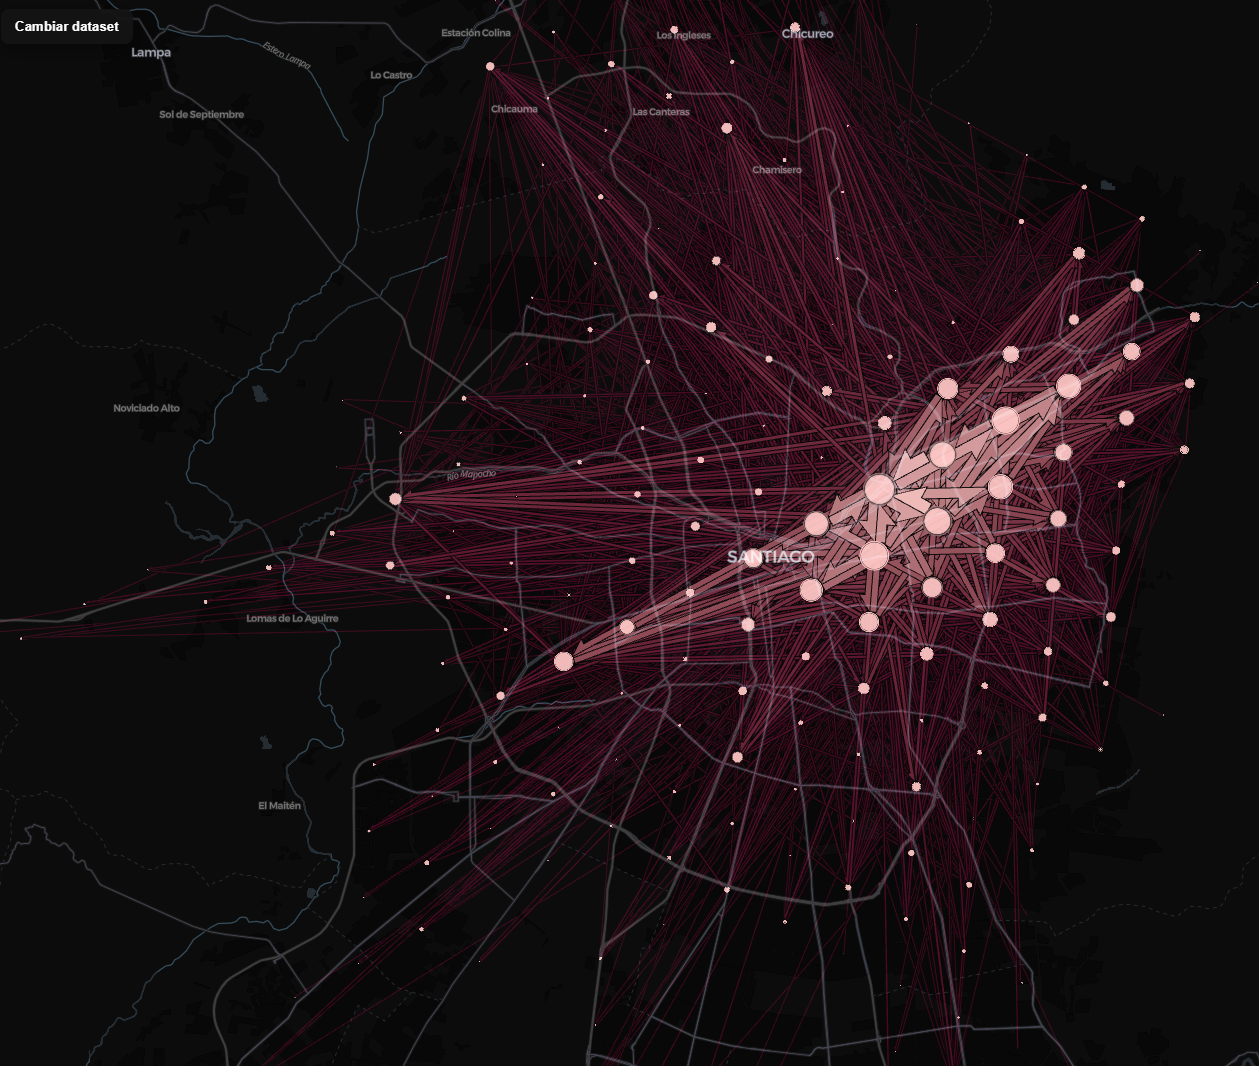

In [31]:
from IPython.display import Image
Image(REPO_ROOT / "images" / "e_awto_baseline.png")

## Captura del flowmap - punta AM


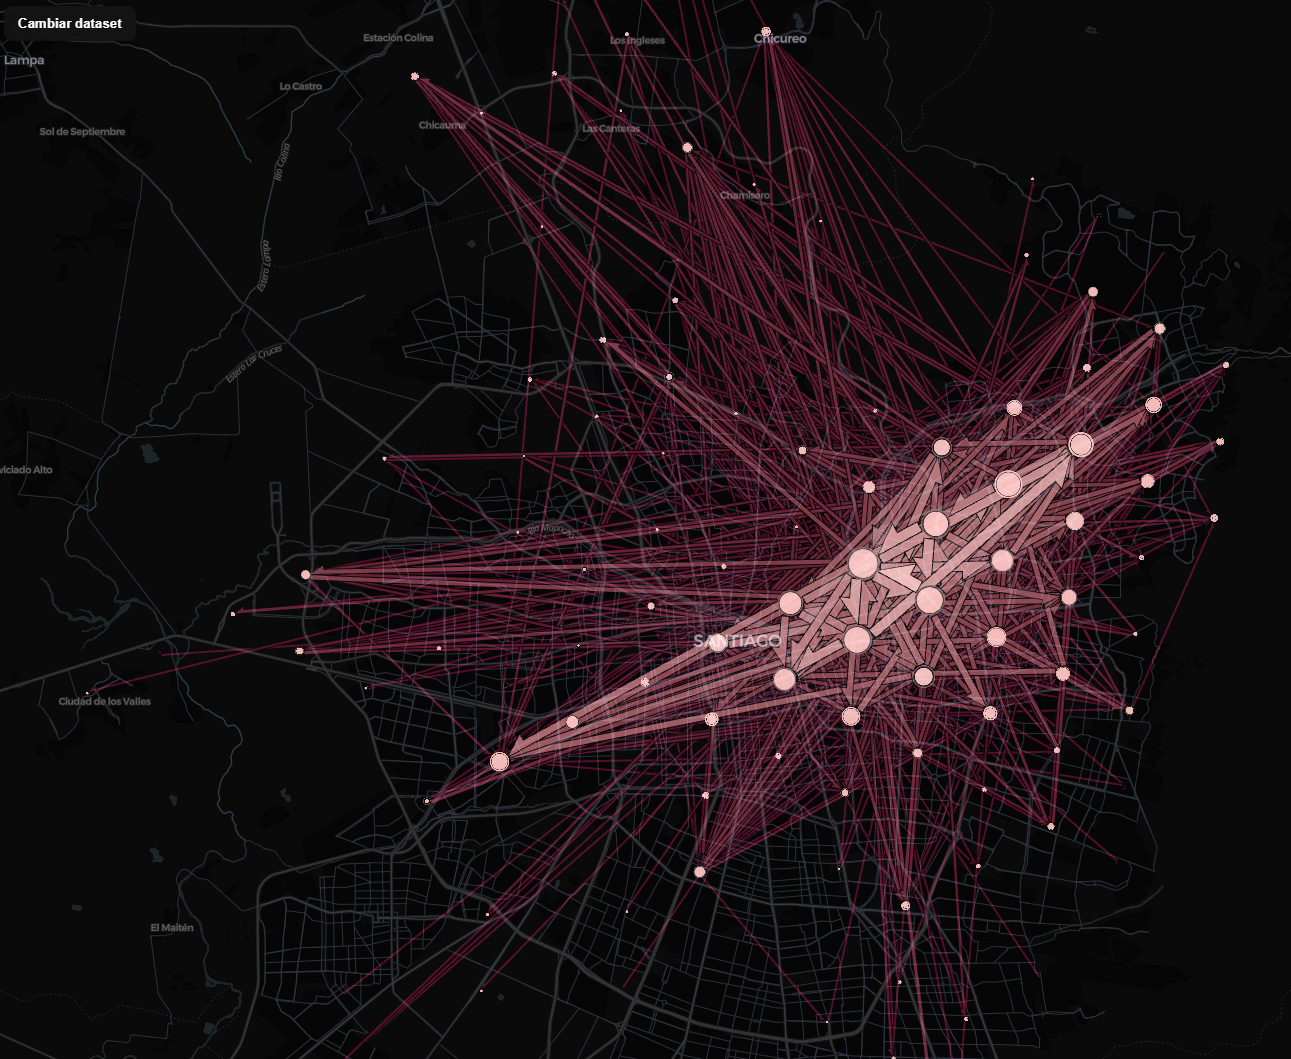

In [32]:
Image(REPO_ROOT / "images" / "e_awto_12_16.png")

## Cierre de la prueba

Esta prueba muestra que no todas las trazas discretas deben tratarse igual. En Awto, la naturaleza vehicular de la fuente hace más razonable una inferencia basada en **clusters consecutivos** que una basada solo en puntos consecutivos.

El notebook deja cuatro aportes principales:

1. un preprocess explícito sobre telemetría vehicular en la RM,
2. una validación formal del bloque de trazas,
3. una inferencia de viajes cluster-based compatible con el contrato general del módulo,
4. y un baseline persistido, acompañado de un contraste temporal opcional que ocurre entre las 12 y las 16 hrs

Con ello, la prueba complementa las demás fuentes de traces del proyecto y demuestra que Pylondrina puede absorber distintos tipos de señal discreta sin tratarlas como si fueran casos idénticos.